# 8. Comparación final y reflexión crítica

Esta sección cierra el proyecto: una sola tabla con los 12 modelos, y después la reflexión que pide el enunciado, pregunta por pregunta, apoyada en la evidencia que ya generamos en las secciones 1 a 7.

In [1]:
import sys
sys.path.insert(0, "../src")
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 160)
sk = pd.read_csv("../outputs/tables/sklearn_results.csv")
sp = pd.read_csv("../outputs/tables/spark_results.csv")
sk["entorno"] = "scikit-learn"; sp["entorno"] = "PySpark"


## 8.1. Tabla comparativa final: los 12 modelos en un solo vistazo

In [2]:
cols = ["entorno","modelo","best_params","cv_auc","test_auc","test_f1","tiempo_entrenamiento_s"]
tabla_final = pd.concat([sk[cols], sp[cols]], ignore_index=True).sort_values("test_auc", ascending=False)
tabla_final_fmt = tabla_final.copy()
for c in ["cv_auc","test_auc","test_f1"]:
    tabla_final_fmt[c] = tabla_final_fmt[c].round(4)
tabla_final_fmt["tiempo_entrenamiento_s"] = tabla_final_fmt["tiempo_entrenamiento_s"].round(1)
tabla_final_fmt.reset_index(drop=True)


,entorno,modelo,best_params,cv_auc,test_auc,test_f1,tiempo_entrenamiento_s
0,scikit-learn,GBT_HistGB,"{""max_depth"": 5, ""max_iter"": 100}",0.7098,0.7393,0.0046,600.4
1,scikit-learn,DecisionTree,"{""max_depth"": 10}",0.6689,0.7368,0.0024,509.1
2,PySpark,GBT,"{""maxIter"": 100, ""maxDepth"": 5}",0.7299,0.7327,0.0089,2950.2
3,PySpark,LogisticRegression,"{""regParam"": 1e-06}",0.7248,0.7232,0.0258,274.7
4,scikit-learn,RandomForest,"{""max_depth"": 15, ""n_estimators"": 100}",0.7109,0.7225,0.0000,6739.3
5,scikit-learn,LogisticRegression,"{""C"": 0.05529260848409784}",0.7141,0.7221,0.0191,70.4
6,PySpark,DecisionTree,"{""maxDepth"": 15}",0.7144,0.7204,0.0262,255.7
7,PySpark,RandomForest,"{""numTrees"": 100, ""maxDepth"": 15}",0.7184,0.7185,0.0000,10597.1
8,PySpark,LinearSVC,"{""regParam"": 1e-06}",0.6755,0.7037,0.0000,567.4
9,PySpark,NaiveBayes,{},0.6998,0.6989,0.2953,49.1


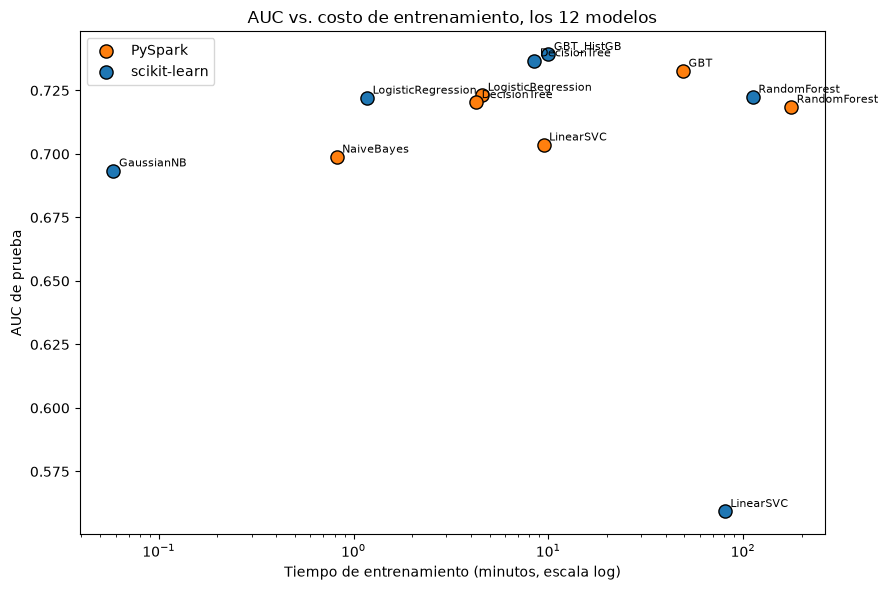

In [3]:
fig, ax = plt.subplots(figsize=(9,6))
colores = {"scikit-learn": "#1f77b4", "PySpark": "#ff7f0e"}
for entorno, grupo in tabla_final.groupby("entorno"):
    ax.scatter(grupo["tiempo_entrenamiento_s"]/60, grupo["test_auc"], s=90, label=entorno,
               color=colores[entorno], edgecolor="black")
    for _, fila in grupo.iterrows():
        ax.annotate(fila["modelo"], (fila["tiempo_entrenamiento_s"]/60, fila["test_auc"]),
                    fontsize=8, xytext=(4,3), textcoords="offset points")
ax.set_xscale("log")
ax.set_xlabel("Tiempo de entrenamiento (minutos, escala log)")
ax.set_ylabel("AUC de prueba")
ax.set_title("AUC vs. costo de entrenamiento, los 12 modelos")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/eda/resumen_final_auc_vs_tiempo.png", dpi=110)
plt.show()


El mejor modelo en cada entorno es un boosting con histogramas (`HistGradientBoostingClassifier` en scikit-learn y `GBTClassifier` en Spark), y los dos quedan muy cerca uno del otro (0,739 contra 0,733), así que ninguno de los dos entornos domina de forma aplastante en desempeño. En tiempo, la nube de puntos deja ver el patrón real: la mayoría de los modelos de PySpark quedan más lentos que su contraparte de scikit-learn, con la notable excepción de `LinearSVC`.

## 8.2. Reflexión final, pregunta por pregunta

### 8.2.1. ¿Qué entorno fue más rápido, y por qué?

In [4]:
total_sk = sk["tiempo_entrenamiento_s"].sum(); total_sp = sp["tiempo_entrenamiento_s"].sum()
print(f"Total scikit-learn: {total_sk:,.1f}s (~{total_sk/60:.1f} min)")
print(f"Total PySpark:      {total_sp:,.1f}s (~{total_sp/60:.1f} min)")
print(f"scikit-learn fue {total_sp/total_sk:.2f}x mas rapido en total.")


Total scikit-learn: 12,761.4s (~212.7 min)
Total PySpark:      14,694.3s (~244.9 min)
scikit-learn fue 1.15x mas rapido en total.


scikit-learn ganó en el total (unas 3 horas 33 minutos contra 4 horas 5 minutos), y gana en 4 de los 6 modelos individuales. La razón principal es el hardware: esta máquina tiene solo 2 núcleos. El paralelismo distribuido de Spark tiene un costo fijo de coordinación (miles de stages, serialización entre tareas, planificación del scheduler) que solo se amortiza cuando hay muchos núcleos, o muchos nodos, entre los que repartir el trabajo. Con solo 2, ese costo casi nunca se paga a sí mismo. La excepción es `LinearSVC`: ahí Spark fue 8,5 veces más rápido y con mejor AUC, pero no por una ventaja de paralelismo, sino porque scikit-learn colapsó a una solución degenerada que, irónicamente, seguía siendo costosa de calcular (`liblinear` iteró 633 veces igual). `DecisionTree`, ya con el error de `rawPrediction`/`probability` corregido (sección 4.2.2), también fue cerca de 2 veces más rápido en Spark. Esa sí es una ventaja limpia de Spark, aunque modesta y aislada a un solo modelo.

### 8.2.2. ¿Qué entorno fue más preciso en AUC?

No hay un ganador único, depende de la familia de modelo:

| Familia | Gana | Diferencia de AUC (sk - sp) | ¿Prácticamente significativo (≥0,005)? |
|---|---|---|---|
| LogisticRegression | (empate) | -0,0011 | No |
| DecisionTree | scikit-learn | +0,0164 | Sí |
| RandomForest | (empate) | +0,0039 | No |
| GBT | scikit-learn | +0,0066 | Sí |
| LinearSVC | PySpark | -0,1443 | Sí (colapso de sklearn) |
| NaiveBayes | PySpark | -0,0055 | Sí (por poco) |

scikit-learn gana con margen real en 2 familias (`DecisionTree` y `GBT`), PySpark gana con margen real en otras 2 (`LinearSVC` y `NaiveBayes`, aunque la de `LinearSVC` es por el colapso de scikit-learn y no por una ventaja algorítmica de Spark), y en las otras 2 (`LogisticRegression` y `RandomForest`) son estadísticamente distintos pero prácticamente equivalentes. El mejor modelo global es `HistGradientBoostingClassifier` de scikit-learn (AUC de 0,739), apenas por encima del `GBTClassifier` de Spark (AUC de 0,733), y no es casualidad que los dos sean el mismo tipo de algoritmo.

### 8.2.3. Significancia estadística contra significancia práctica

Con 452.141 filas de prueba, la significancia estadística deja de ser informativa por sí sola. De las 44 comparaciones de AUC que hicimos en este proyecto (36 de DeLong en la sección 5 más 8 de McNemar y bootstrap en la sección 6), prácticamente todas rechazan la hipótesis nula, porque el tamaño de muestra por sí solo garantiza detectar cualquier diferencia que no sea exactamente cero, sin importar cuán chica. El umbral de significancia práctica que declaramos de antemano (diferencia de AUC mayor o igual a 0,005, sección 5) es lo que realmente separa las diferencias que importan de las que no: de las 6 comparaciones entre entornos, 4 son prácticamente relevantes (`DecisionTree`, `GBT`, `LinearSVC`, `NaiveBayes`) y 2 no lo son (`LogisticRegression`, `RandomForest`), aunque las 6 sean \"significativas\". La lección metodológica central del proyecto es que declarar el umbral de relevancia práctica antes de mirar los datos es lo único que evita concluir que dos modelos son diferentes cuando en realidad la diferencia es demasiado chica para cambiar qué modelo se elegiría en producción.

### 8.2.4. Diferencias de implementación que explican las discrepancias

Dos de las discrepancias que en un primer momento parecían diferencias algorítmicas entre librerías resultaron ser errores propios, no diferencias reales. En `DecisionTree` (sección 4.2.2), usamos `rawPredictionCol=\"rawPrediction\"` para seleccionar y evaluar el modelo, cuando el puntaje que realmente guardamos venía de `probability`. Para un árbol individual esas dos columnas no son equivalentes en el orden que producen (sí lo son para modelos de conjunto). Al corregirlo, la brecha bajó de 14 puntos de AUC a menos de 2. La diferencia que queda (cerca de 1,7 puntos) es probablemente real, y se puede atribuir a `maxBins=32` (Spark discretiza las variables continuas en como máximo 32 puntos de corte candidatos, mientras que scikit-learn evalúa cualquier punto real). En `NaiveBayes` (sección 4.6c) encontramos exactamente el mismo bug, con el mismo mecanismo, y al corregirlo la \"diferencia real de implementación\" que habíamos documentado al principio (0,564 contra 0,694) desapareció por completo (0,699 contra 0,694, prácticamente empatados).

Una diferencia que sí resultó ser real y la entendemos bien es la de `LinearSVC`: colapsó en scikit-learn (`liblinear`, descenso de coordenadas dual) pero no en Spark (OWL-QN, cuasi-Newton). Son dos optimizadores distintos explorando la misma superficie de pérdida de forma distinta, y uno de ellos quedó atrapado en una solución degenerada para este problema desbalanceado (secciones 3.7 y 4.6b).

Y una diferencia de implementación que no afecta el AUC pero sí la interpretabilidad (sección 7.1): el `OneHotEncoder` de scikit-learn y el de Spark, con la misma configuración conceptual, producen espacios de variables de distinta dimensión (114 contra 107) por cómo cada uno trata la categoría nula o no vista.

La lección que se repite en los tres casos es la misma: un error de implementación propio puede parecer, a primera vista, una diferencia legítima entre librerías, y solo se distingue verificando explícitamente, modelo por modelo, que el puntaje reportado coincide con el que realmente se usa en el resto del pipeline.

### 8.2.5. DeLong contra McNemar y bootstrap: ¿coinciden, y qué le falta a DeLong?

In [5]:
delong_between = pd.read_csv("../outputs/tables/delong_between_envs.csv")
mcnemar_res = pd.read_csv("../outputs/tables/mcnemar_resultados.csv")
boot_res = pd.read_csv("../outputs/tables/bootstrap_resultados.csv")
print(f"DeLong:            {len(delong_between)+30} comparaciones (36 en total, seccion 5), todas rechazan H0 tras Holm")
print(f"McNemar:           {len(mcnemar_res)} comparaciones (seccion 6), {mcnemar_res['rechaza_h0_holm_0.05'].sum()}/{len(mcnemar_res)} rechazan H0 tras Holm")
print(f"Bootstrap pareado: {len(boot_res)} comparaciones (seccion 6), {boot_res['auc_excluye_cero'].sum()}/{len(boot_res)} excluyen 0 en el IC95%")


DeLong:            36 comparaciones (36 en total, seccion 5), todas rechazan H0 tras Holm
McNemar:           8 comparaciones (seccion 6), 8/8 rechazan H0 tras Holm
Bootstrap pareado: 8 comparaciones (seccion 6), 8/8 excluyen 0 en el IC95%


Las tres pruebas coinciden en dirección y en significancia estadística en las 8 comparaciones que tienen en común (tabla resumen de la sección 6.5), lo cual es una buena señal de consistencia interna, aunque esperable con este tamaño de muestra. DeLong compara el ranking (AUC) con una fórmula analítica exacta. McNemar compara los aciertos a un umbral fijo, de forma complementaria y no como sustituto, porque puede cambiar de conclusión si cambia el umbral. El bootstrap da un intervalo de confianza empírico, sin asumir normalidad asintótica, tanto para AUC como para métricas que DeLong no cubre (AUC-PR y F1). Las limitaciones específicas de DeLong (solo AUC, asintótica, sensible al tamaño de muestra, sección 5.8) son exactamente lo que McNemar y el bootstrap vienen a compensar.

### 8.2.6. ¿A qué volumen de datos empezaría PySpark a superar a scikit-learn?

Con los datos de este proyecto (1,8 millones de filas de entrenamiento, alrededor de 114 columnas ya con one-hot, que caben cómodamente en los 4 GB de memoria asignados) no hay ninguna razón estructural para que Spark gane. El cuello de botella no es memoria ni cómputo que no entre en una sola máquina, así que el paralelismo distribuido solo añade overhead de coordinación sin nada que lo compense. La ventaja de Spark aparecería en dos escenarios, ninguno presente aquí: un dataset que no entra en la memoria de una sola máquina (varias decenas de GB o más, forzando el uso de disco o haciendo imposible usar scikit-learn), o un clúster real con muchos nodos y núcleos (no 2, sino decenas o cientos), donde el trabajo sí se reparte de forma efectiva y el costo fijo de coordinación se amortiza sobre mucho más cómputo útil. Ninguna de las dos condiciones se cumple con 2 núcleos y medio gigabyte de datos ya preprocesados, así que en este proyecto no hay ningún punto de la curva de tamaño de datos donde Spark hubiera empezado a ganar sin cambiar también el hardware.

### 8.2.7. Contribución y limitaciones de LIME, especialmente sobre un modelo distribuido

LIME sí aportó algo que ninguna de las pruebas globales (DeLong, McNemar, bootstrap) puede dar: una explicación por caso individual, útil para entender un error concreto del modelo (secciones 7.2 y 7.3) en vez de solo su desempeño agregado. El hallazgo más interesante no fue una variable en particular, sino un patrón que se repitió en los dos entornos: el ajuste lineal local de LIME fue sistemáticamente peor (`R²` de alrededor de 0,09) para los falsos negativos que para los falsos positivos (`R²` entre 0,36 y 0,44), lo cual sugiere que los incumplimientos \"sorpresa\" caen en zonas más no lineales del espacio de variables. Las limitaciones son las de siempre (inestabilidad por el muestreo aleatorio, ruido de docenas de columnas dummy con peso marginal) más una específica de Spark: no existe una implementación nativa, así que tuvimos que escribir a mano un adaptador que convierte cada lote de muestras perturbadas a DataFrame, lo pasa por `.transform()`, y lo trae de vuelta a NumPy (sección 7.3). Funcionó bien para explicar un puñado de casos (1 a 3 segundos cada uno), pero ese costo por instancia haría impráctico generar explicaciones para miles de casos de forma rutinaria sin un rediseño, por ejemplo procesando muchas instancias en un solo lote en vez de una por una.

### 8.2.8. Efecto de cada condición obligatoria del enunciado

- Usar un split y un preprocesamiento compartido entre los dos entornos fue la condición que hizo posible todo lo demás. Sin las mismas 452.141 filas de prueba en el mismo orden lógico (mismos id), no existiría DeLong, ni McNemar, ni el bootstrap pareado tal como los aplicamos, porque los tres dependen de comparar observaciones pareadas y no muestras independientes.
- Usar `cv=3` / `numFolds=3` en vez de 5 o 10 fue más barato, y era indispensable porque cada combinación de hiperparámetros para `RandomForest` y `GBT` ya tomaba varios minutos, pero también es más ruidoso. Esto puede explicar, junto con `maxBins`, por qué `DecisionTree` eligió una profundidad distinta en cada entorno (10 en scikit-learn, 15 en Spark): con solo 3 particiones, la estimación de AUC de validación cruzada tiene más varianza, y el óptimo elegido puede cambiar de una corrida a otra.
- No usar un objeto `Pipeline` en scikit-learn (preprocesamiento explícito y separado, sección 2) hace que todo sea más transparente y más fácil de revisar paso a paso, aunque el costo es más responsabilidad manual para mantener sincronizados train y test y para no filtrar información, algo que sí vigilamos de forma activa, por ejemplo al elegir el umbral de Youden solo con datos de entrenamiento (sección 6.1).
- Usar una configuración de Spark reducida y justificada para el hardware real (2 núcleos, 4g/4g, `shuffle.partitions=8` en vez de los 400 \"de fábrica\") la documentamos de forma explícita en `src/model_pyspark.py`. En el fondo, es la misma razón detrás de la respuesta a 8.2.1 y 8.2.6: con este hardware, cualquier configuración de Spark iba a chocar con el mismo techo estructural.

## 8.3. Conclusión general

Los dos entornos llegan a un techo predictivo muy parecido (entre 0,72 y 0,74 de AUC), con el mismo tipo de modelo (boosting con histogramas) ganando en los dos. Para este dataset en particular (1,8 millones de filas, una sola máquina de 2 núcleos), elegir entre scikit-learn y PySpark no cambia la conclusión de negocio de forma sustancial. Lo que sí cambia, y de forma importante, es qué tan seguros podemos estar de esa conclusión: la comparación rigurosa (mismo split, tres pruebas estadísticas complementarias, un umbral de significancia práctica declarado de antemano) fue lo que nos permitió distinguir diferencias reales (el colapso de `LinearSVC`, la ventaja genuina pero modesta de `DecisionTree` en Spark) de errores de implementación propios que, sin esa verificación cruzada, habrían quedado documentados, de forma incorrecta, como hallazgos sobre las librerías. Encontrar y corregir esos dos errores (secciones 4.2.2 y 4.6c) es, en un sentido real, el resultado más valioso de todo el ejercicio. Más que cualquier número de AUC, es la evidencia de que la metodología de comparación que exigía el enunciado cumplió exactamente la función para la que está pensada.